# Notebook 14 — MES–M2K delayed entry and leg-level cross-correlation

**D-022 (pre-registration) → D-023 (verdict) · EXP-019 · validation report 14.**

Runs: part 1 (Z0 half) *Creative Tan Antelope* · part 2 (Z2 half + cross-correlation)
*Swimming Red Pigeon* — QC project 34720894. This notebook only RE-READS the banked
machine-readable CSVs; every number here is recomputed by
`spread_research.delayed_entry_summary` and pinned by unit test, so the notebook
cannot drift from its own evidence.

**Question:** is the MES–M2K conditional surface the thin leg catching up (L-014),
or convergence that survives a delayed entry? **Ceiling (fixed in advance):** no
outcome advances the pair — criterion (b) is inherited and failing, the window is
spent, and the D-019 no-go cannot change.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
import pandas as pd
from spread_research.delayed_entry_summary import delayed_entry_summary

MR = pathlib.Path.cwd().parent / "reports" / "machine_readable"
grids = pd.read_csv(MR / "nb14_MES_M2K_delay_grids.csv")
xc = pd.read_csv(MR / "nb14_MES_M2K_crosscorr.csv")
scal = pd.read_csv(MR / "nb14_MES_M2K_scalars.csv")
s = delayed_entry_summary(grids, xc)
print("VERDICT:", s["verdict"])
print(f"read set: {s['n_included']}/37 included ({s['n_excluded']} excluded)")
for d in (2, 5, 15):
    print(f"  rho({d:>2}) = {s[f'rho_{d}']:.3f}   [Z0 {s[f'rho_{d}_z0']:.3f} | Z2 {s[f'rho_{d}_z2']:.3f}]   S({d}) = {s[f'S_{d}']:.2f}")
print(f"  X = {s['X']}  (ab_1 = {s['ab_1']:+.4f} ci_lo {s['ab_1_ci_lo']:+.4f}; "
      f"asym_1 = {s['asym_1']:+.4f} ci_lo {s['asym_1_ci_lo']:+.4f}; c0 = {s['c0']:.3f})")

VERDICT: DELAY-ROBUST
read set: 37/37 included (0 excluded)
  rho( 2) = 0.932   [Z0 0.929 | Z2 0.932]   S(2) = 0.95
  rho( 5) = 0.849   [Z0 0.882 | Z2 0.843]   S(5) = 0.73
  rho(15) = 0.536   [Z0 0.673 | Z2 0.453]   S(15) = 0.59
  X = True  (ab_1 = +0.0330 ci_lo +0.0205; asym_1 = +0.0289 ci_lo +0.0135; c0 = 0.788)


In [2]:
# The eight validity gates, as recorded by the ingest (read before anything else)
gates = scal[scal["key"].str.startswith("D022_")]
for _, r in gates.iterrows():
    print(f"{r['key']:<38} {str(r['value'])[:90]}")

D022_GATE_4_PART_1_EMISSION            PASS|54 keys, set-identical to the part-1 manifest
D022_GATE_4_PART_2_EMISSION            PASS|57 keys, set-identical to the part-2 manifest
D022_GATE_1_Z0_VS_NB02                 PASS|60 cells reproduced exactly
D022_GATE_1_Z2_VS_NB06                 PASS|60 cells reproduced exactly
D022_GATE_2_PART_1_MATCHED             PASS|n_events constant across {1,2,5,15} in all 40 cells
D022_GATE_2_PART_2_MATCHED             PASS|n_events constant across {1,2,5,15} in all 40 cells
D022_GATE_2B_CROSS_PART                PASS|7 shared diagnostics identical
D022_GATE_3_CROSSCORR                  PASS|c0 = 0.788, 15 finite CIs, 1000 replicates


In [3]:
# Headline cells across delays (matched event sets -> n constant per row)
g = grids.copy(); g["signal"] = g["signal"].astype(str)
m = g[g["matched"].astype(bool)].set_index(["signal", "spec", "entry_z", "horizon_bars"])
for sig, spec, ez, h, label in [("2", "S1", 3.0, 120, "Z2 S1 3.0/120 (largest honest cell)"),
                                ("0", "S1", 3.0, 60,  "Z0 S1 3.0/60 (highest honest t)")]:
    rows = m.loc[(sig, spec, ez, h)].sort_values("delay")
    cells = " | ".join(f"d={int(r.delay)}: {r.mean_session_bps:+.2f} bps (t {r.t_clustered:.1f})"
                       for r in rows.itertuples())
    print(label)
    print("  " + cells + f"  [n={int(rows['n_events'].iloc[0])}]")
    print()

Z2 S1 3.0/120 (largest honest cell)
  d=1: +6.68 bps (t 5.1) | d=2: +5.89 bps (t 4.7) | d=5: +4.74 bps (t 3.9) | d=15: +2.24 bps (t 1.9)  [n=2057]

Z0 S1 3.0/60 (highest honest t)
  d=1: +5.62 bps (t 5.7) | d=2: +5.25 bps (t 5.5) | d=5: +4.75 bps (t 5.1) | d=15: +3.06 bps (t 3.6)  [n=3728]



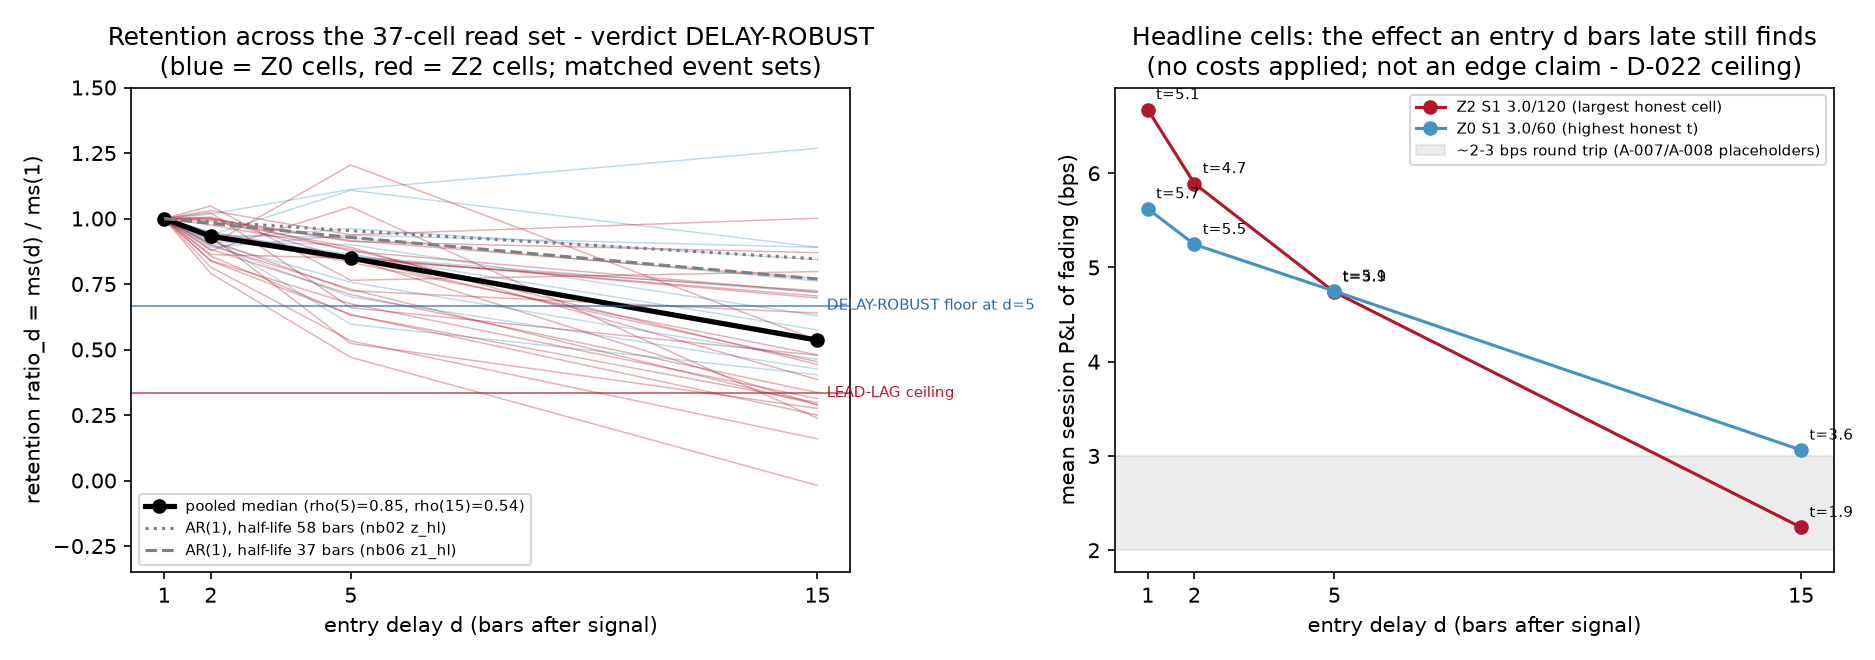

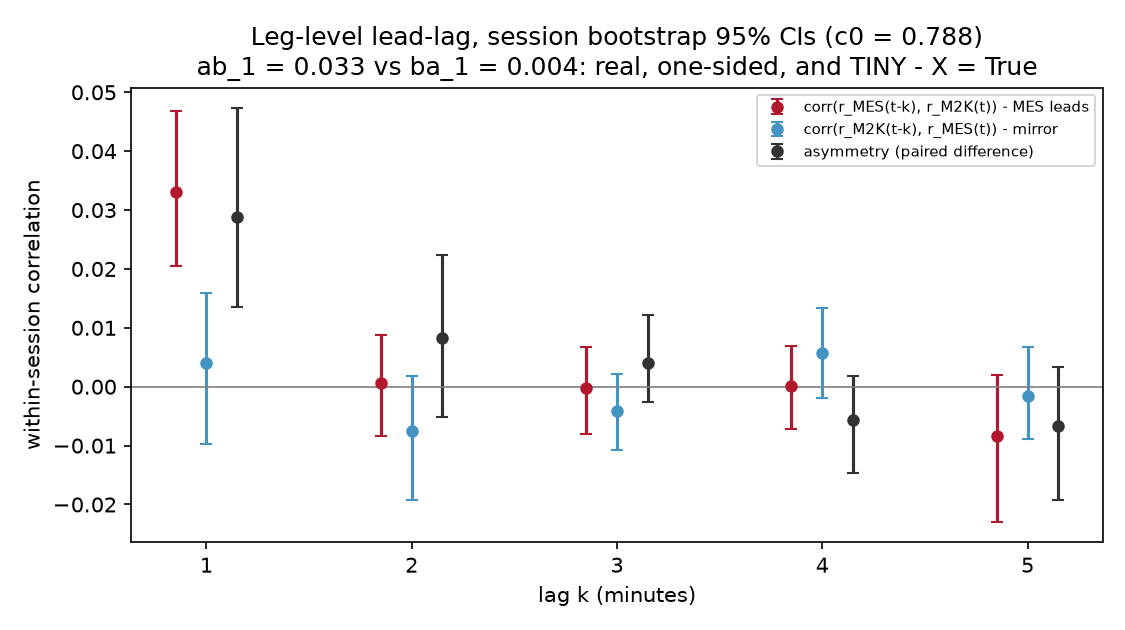

In [4]:
from IPython.display import Image, display
FIG = pathlib.Path.cwd().parent / "reports" / "figures"
display(Image(str(FIG / "nb14_MES_M2K_delay_decay.png")))
display(Image(str(FIG / "nb14_MES_M2K_crosscorr.png")))

## Reading (D-023, within the pre-registered ceiling)

**DELAY-ROBUST.** The surface survives entry five and fifteen minutes late; a
catch-up mechanism predicts ~0 by d = 5. The leg-level lead-lag is real but one
bar deep and ~0.03 of correlation — already excluded by the t+1 convention, so it
is not the carrier. D-015's [PLAUSIBLE] lead-lag attribution is withdrawn as the
surface's explanation (amended inline in reports 02/13 and L-014); the thin-leg
base-sampling discipline binds unchanged, and the criterion-(b) evaporation at
coarse bars becomes an open puzzle rather than an explained artifact.

**Nothing advances.** Hypothesis-generating only: the session/resolution thread
now has a banked target — +6.68 bps decaying to +2.24 bps across a 15-minute
entry delay in the thinnest micro in the universe. Not an edge claim
(A-007/A-008 placeholders; 1,300 cells examined on this spent window).